In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

pd.set_option('display.max_columns',None)

In [3]:
df = pd.read_csv("Walmart_Cleaned_Data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Quarter,Day
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,1,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010,2,6,1,12
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010,2,7,1,19
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010,2,8,1,26
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010,3,9,1,5


In [4]:
print(df.shape)

df.info()

df.describe()

(421570, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Year,Month,Week,Quarter,Day
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,60.090059,3.361027,2590.074819,879.974298,468.087665,1083.132268,1662.772385,171.201947,7.960289,136727.915739,2010.968591,6.449510,25.826762,2.482767,15.673131
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,34875.000000,2010.000000,1.000000,1.000000,1.000000,1.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,93638.000000,2010.000000,4.000000,14.000000,2.000000,8.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000,140167.000000,2011.000000,6.000000,26.000000,2.000000,16.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000,202505.000000,2012.000000,9.000000,38.000000,3.000000,23.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000,2012.000000,12.000000,52.000000,4.000000,31.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,6052.385934,5084.538801,5528.873453,3894.529945,4207.629321,39.159276,1.863296,60980.583328,0.796876,3.243217,14.151887,1.071341,8.753549


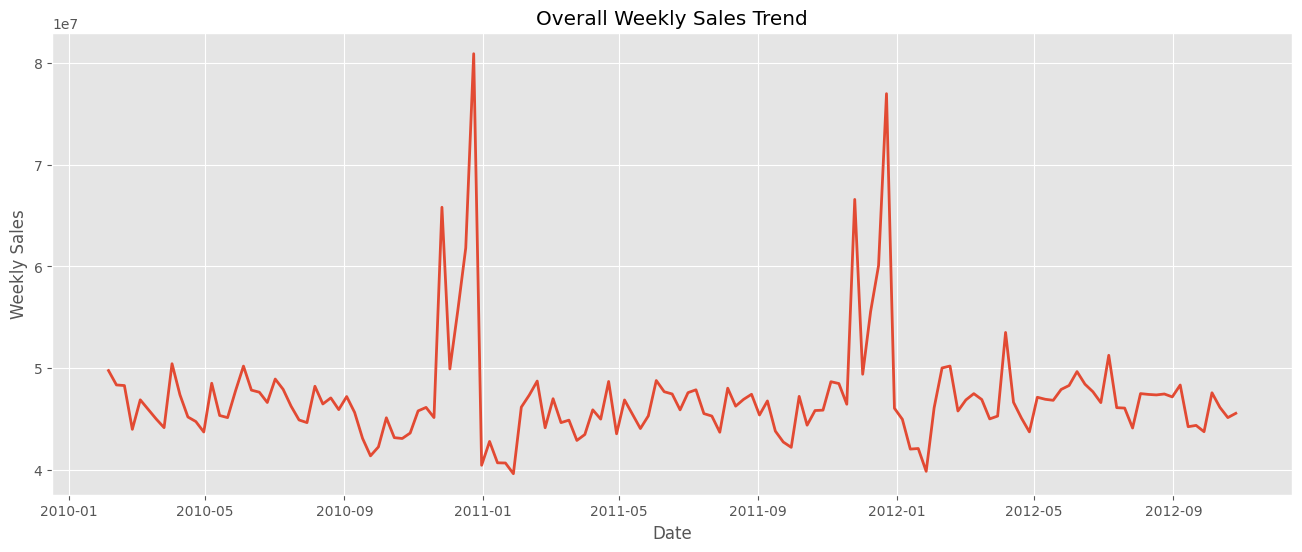

In [5]:
weekly_sales = df.groupby("Date")["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(16,6))

plt.plot(weekly_sales["Date"],
         weekly_sales["Weekly_Sales"],
         linewidth=2)

plt.title("Overall Weekly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.show()

- Observed seasonal peaks and dips.
- Holiday weeks typically show sharp increases.
- Useful for understanding long-term demand patterns.

- Weekly sales fluctuate over time with noticeable peaks during specific weeks.
Sales remain relatively stable for most weeks but increase sharply during holiday periods.

- The sales trend indicates seasonal demand patterns, with holiday periods generating significantly higher revenue. Walmart should proactively increase inventory and workforce allocation before these peak demand weeks to avoid stockouts and maximize sales opportunities.


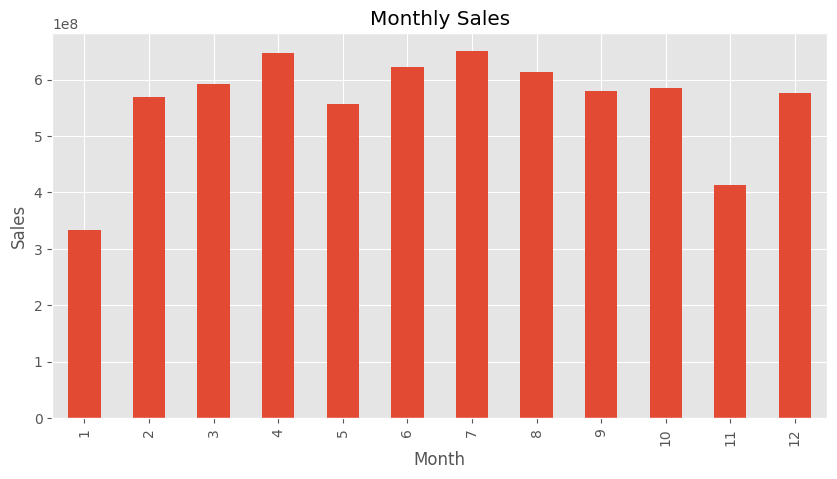

In [6]:
monthly_sales = df.groupby("Month")["Weekly_Sales"].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(kind='bar')

plt.title("Monthly Sales")

plt.ylabel("Sales")

plt.show()

- Monthly Sales Trend

- Sales vary across months, with certain months consistently recording higher sales.

- Monthly sales analysis reveals recurring seasonal patterns. High-performing months should receive additional inventory planning and promotional support, while lower-performing months present opportunities for targeted marketing campaigns to stimulate demand.


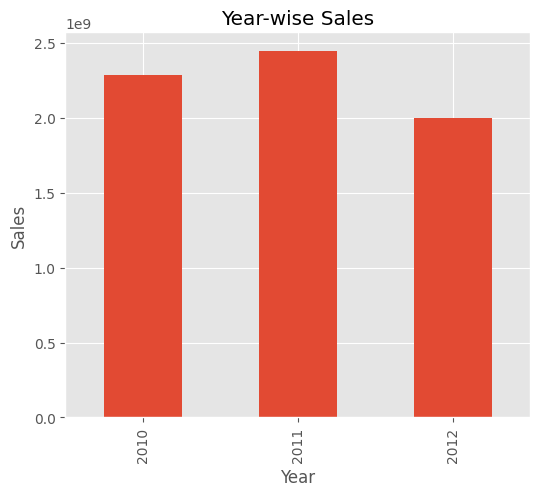

In [7]:
year_sales = df.groupby("Year")["Weekly_Sales"].sum()

plt.figure(figsize=(6,5))

year_sales.plot(kind="bar")

plt.title("Year-wise Sales")

plt.ylabel("Sales")

plt.show()

- Year-wise Sales

- Total annual sales changed across the observed years.

- Year-over-year sales comparison helps management evaluate business growth. An increasing trend suggests improved market performance, whereas declining sales may indicate changes in customer behavior, economic conditions, or competitive pressure.


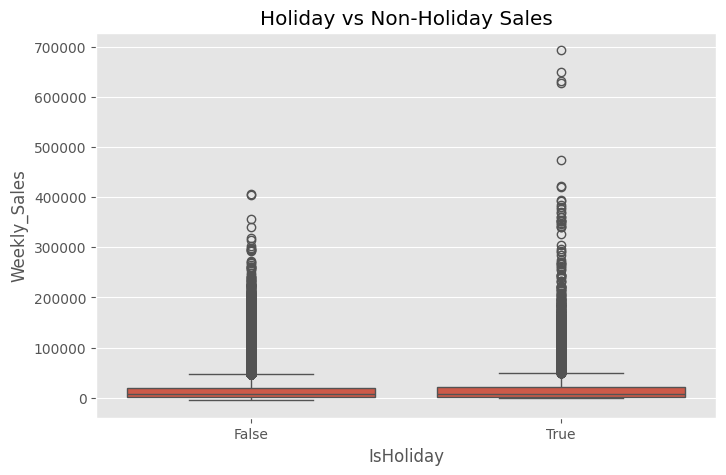

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(x="IsHoliday",
            y="Weekly_Sales",
            data=df)

plt.title("Holiday vs Non-Holiday Sales")

plt.show()

- Holiday vs Non-Holiday Sales

- Holiday weeks generally exhibit higher sales and greater variability than non-holiday weeks.

- Holiday events have a substantial impact on consumer purchasing behavior. Walmart should strengthen inventory availability, staffing, and promotional campaigns during holiday periods to capitalize on increased customer demand.



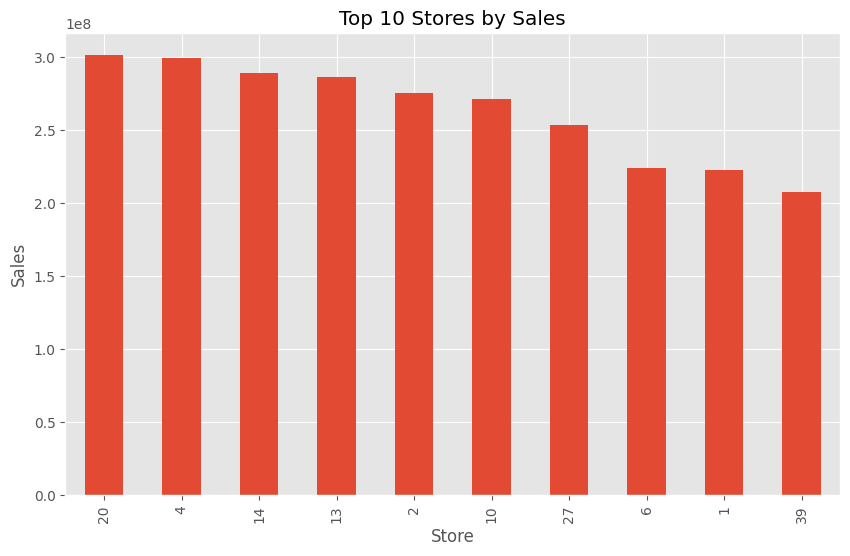

In [9]:
top_store = df.groupby("Store")["Weekly_Sales"].sum()

top_store = top_store.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_store.plot(kind='bar')

plt.title("Top 10 Stores by Sales")

plt.ylabel("Sales")

plt.show()

- Top 10 Stores

- A small number of stores contribute a disproportionately large share of total sales.

- These high-performing stores are major revenue drivers and should receive priority for inventory allocation, promotional budgets, and operational support. Their practices may also serve as benchmarks for improving performance in other locations.



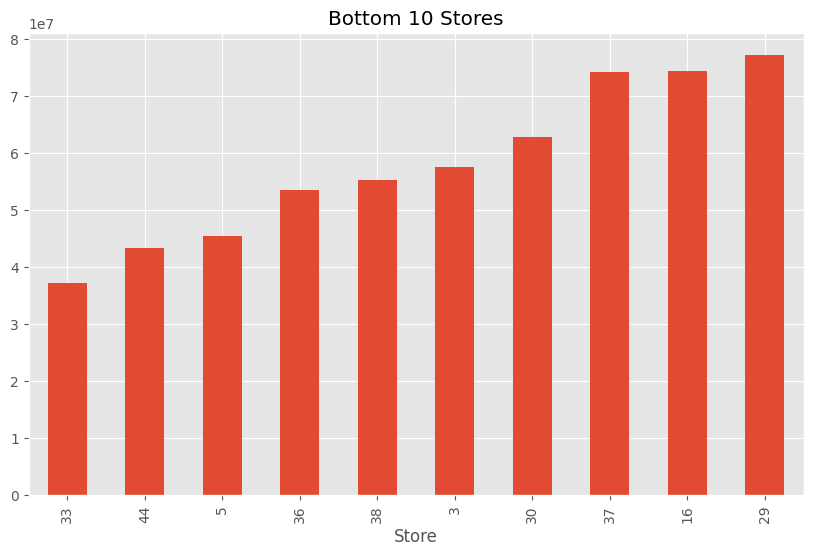

In [10]:
bottom_store = df.groupby("Store")["Weekly_Sales"].sum()

bottom_store = bottom_store.sort_values().head(10)

plt.figure(figsize=(10,6))

bottom_store.plot(kind='bar')

plt.title("Bottom 10 Stores")

plt.show()

- Bottom 10 Stores

- Some stores consistently generate much lower sales than others.

- Lower-performing stores require further investigation to determine whether their performance is influenced by location, customer demographics, competition, or operational inefficiencies. Management may consider localized marketing or assortment optimization.



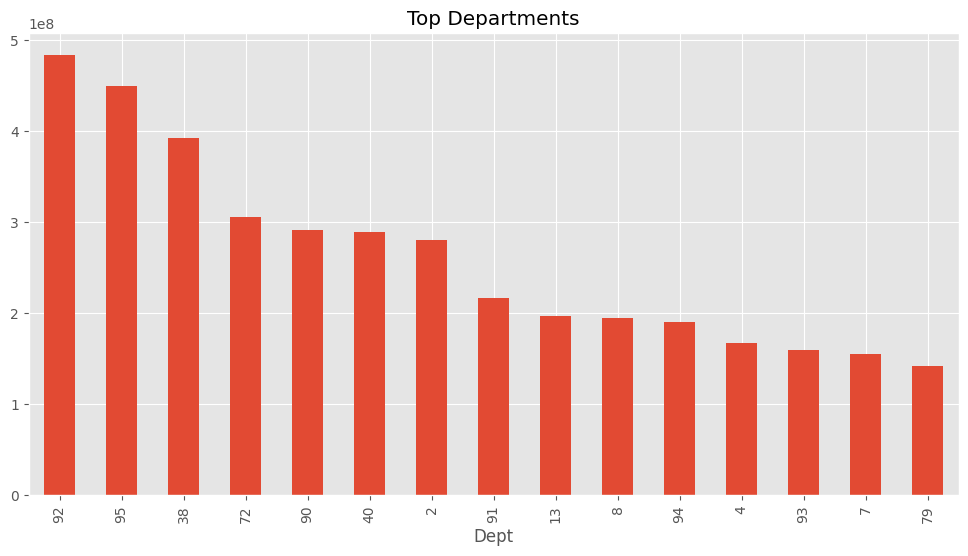

In [11]:
dept = df.groupby("Dept")["Weekly_Sales"].sum()

dept = dept.sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))

dept.plot(kind="bar")

plt.title("Top Departments")

plt.show()

- Department-wise Sales

- Sales are unevenly distributed across departments, with a few departments contributing significantly more revenue.

- High-performing departments should receive greater inventory investment and promotional focus. Departments with consistently lower sales should be reviewed for pricing, product assortment, or merchandising improvements.


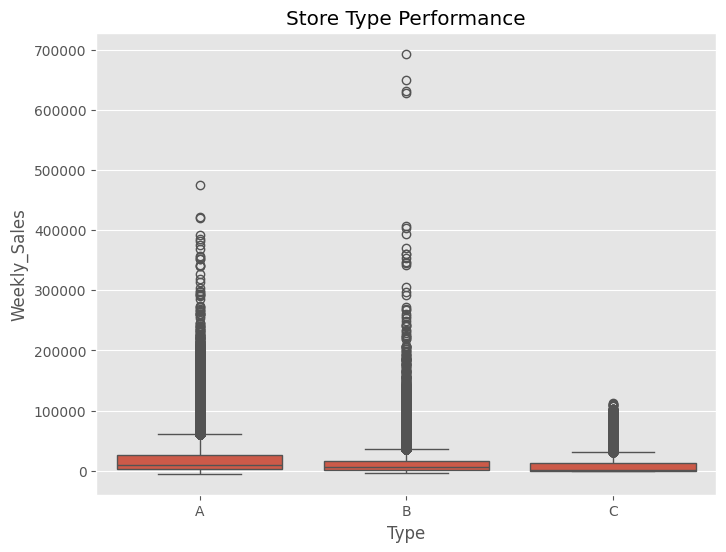

In [12]:
plt.figure(figsize=(8,6))

sns.boxplot(x="Type",
            y="Weekly_Sales",
            data=df)

plt.title("Store Type Performance")

plt.show()

- Store Type Analysis

- Store Types A, B, and C show different sales distributions.

- Store format significantly influences sales performance. Larger store formats generally attract higher customer traffic and generate greater revenue, suggesting that expansion strategies should consider store type and local demand characteristics.


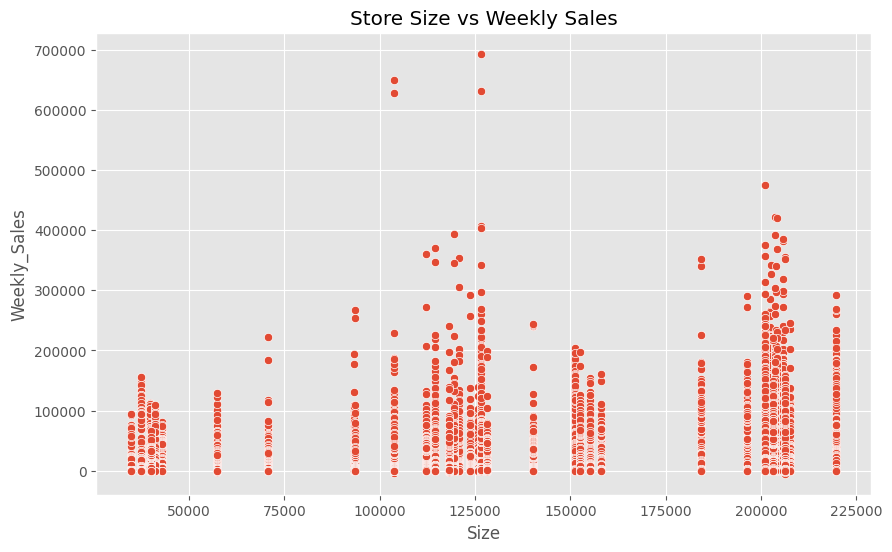

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(x="Size",
                y="Weekly_Sales",
                data=df)

plt.title("Store Size vs Weekly Sales")

plt.show()

- Store Size vs Weekly Sales

- Larger stores tend to record higher weekly sales, although the relationship is not perfectly linear.

- Store size positively influences sales potential; however, other factors such as location, customer preferences, and operational efficiency also affect overall performance. Inventory decisions should therefore consider multiple variables rather than store size alone.

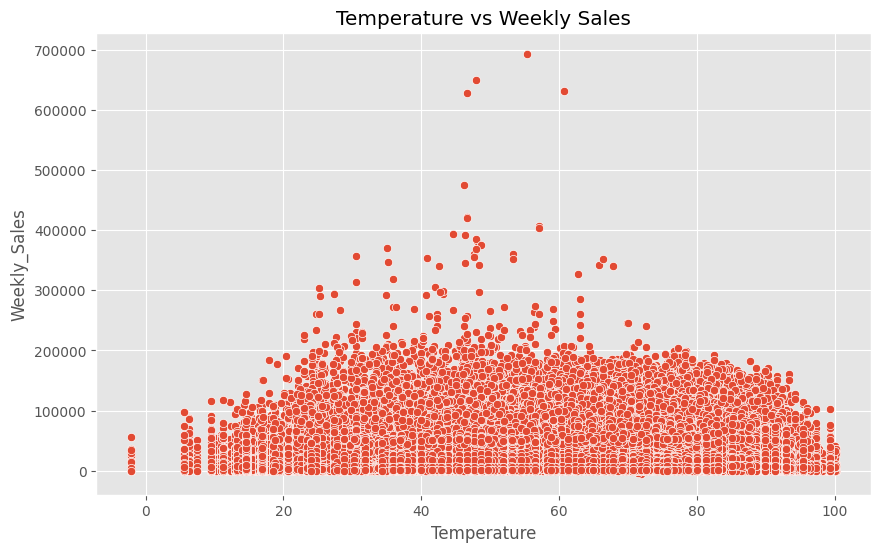

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(x="Temperature",
                y="Weekly_Sales",
                data=df)

plt.title("Temperature vs Weekly Sales")

plt.show()

- Temperature vs Weekly Sales

- Temperature does not exhibit a strong relationship with weekly sales.

- Weather appears to have only a limited influence on Walmart's overall sales performance. Inventory planning should primarily rely on seasonal demand and historical sales rather than temperature alone.

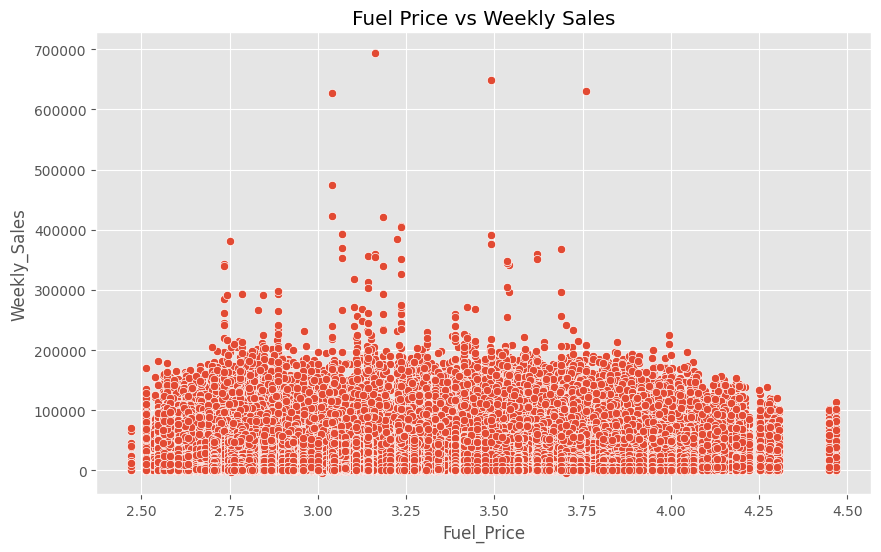

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(x="Fuel_Price",
                y="Weekly_Sales",
                data=df)

plt.title("Fuel Price vs Weekly Sales")

plt.show()

- Fuel Price vs Weekly Sales

- Weekly sales remain relatively stable despite fluctuations in fuel prices.

- Fuel price changes have minimal direct impact on customer purchasing behavior within the observed period. Other variables such as holidays, promotions, and seasonal demand are likely to be stronger drivers of sales.


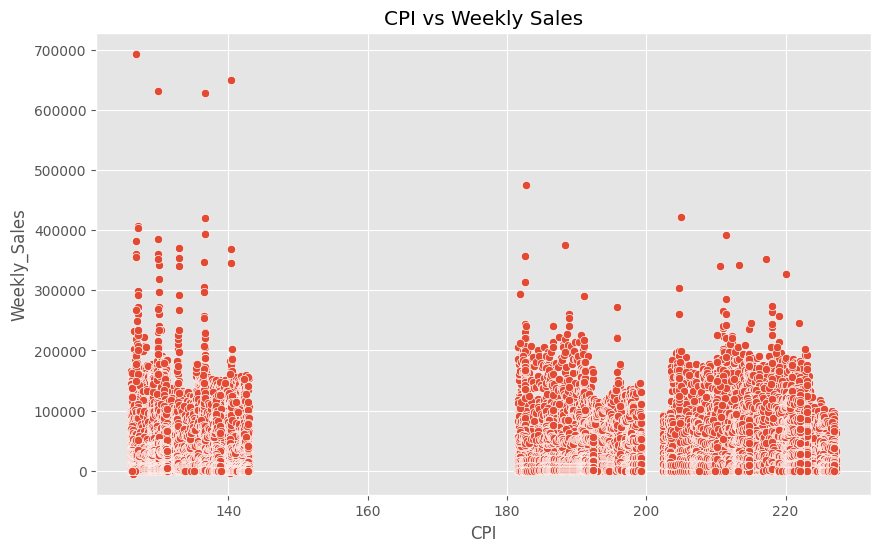

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(x="CPI",
                y="Weekly_Sales",
                data=df)

plt.title("CPI vs Weekly Sales")

plt.show()

- CPI vs Weekly Sales

- Consumer Price Index values show only a weak relationship with weekly sales.

- Inflation does not appear to significantly affect short-term purchasing patterns in this dataset. Nevertheless, CPI remains an important macroeconomic indicator that should be monitored in long-term demand forecasting.


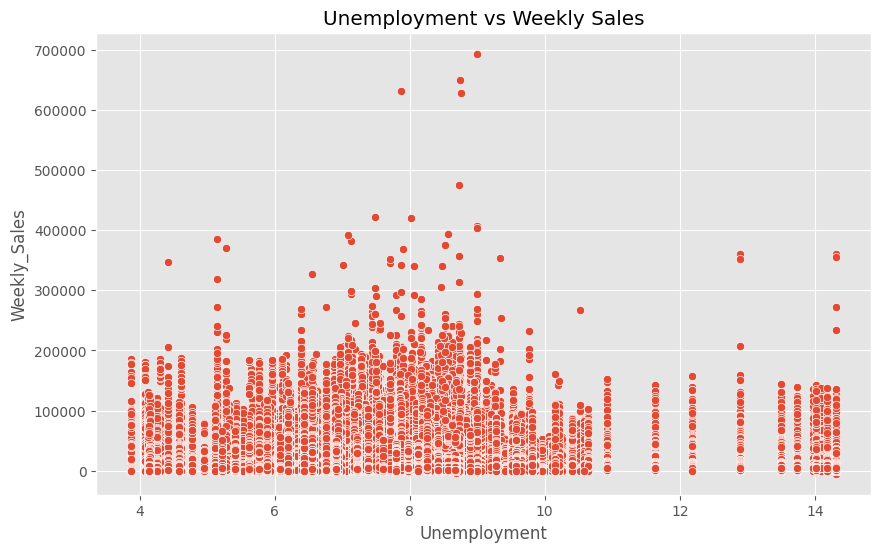

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(x="Unemployment",
                y="Weekly_Sales",
                data=df)

plt.title("Unemployment vs Weekly Sales")

plt.show()

- Unemployment vs Weekly Sales

- Weekly sales show limited correlation with unemployment levels.

- Changes in unemployment rates have little immediate effect on weekly sales, suggesting that routine consumer purchases remain relatively stable despite labor market fluctuations.


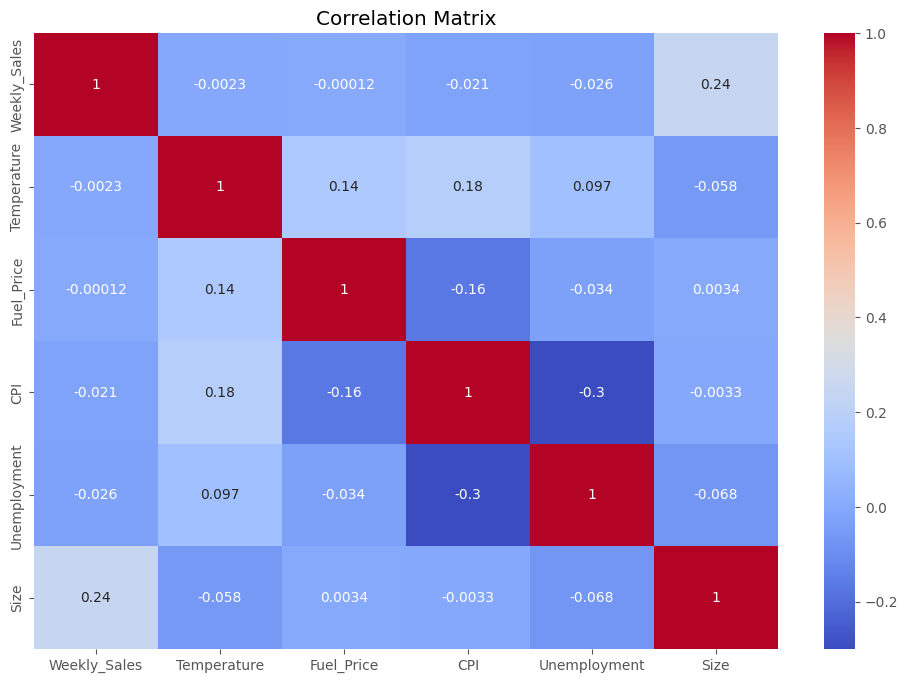

In [18]:
plt.figure(figsize=(12,8))

corr = df[[
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Size"
]].corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

- Correlation Heatmap

- Most numerical variables exhibit weak correlations with weekly sales.

- Sales are influenced by multiple interacting factors rather than any single variable. This supports the use of forecasting models capable of capturing seasonality and temporal patterns instead of relying solely on simple correlation analysis.


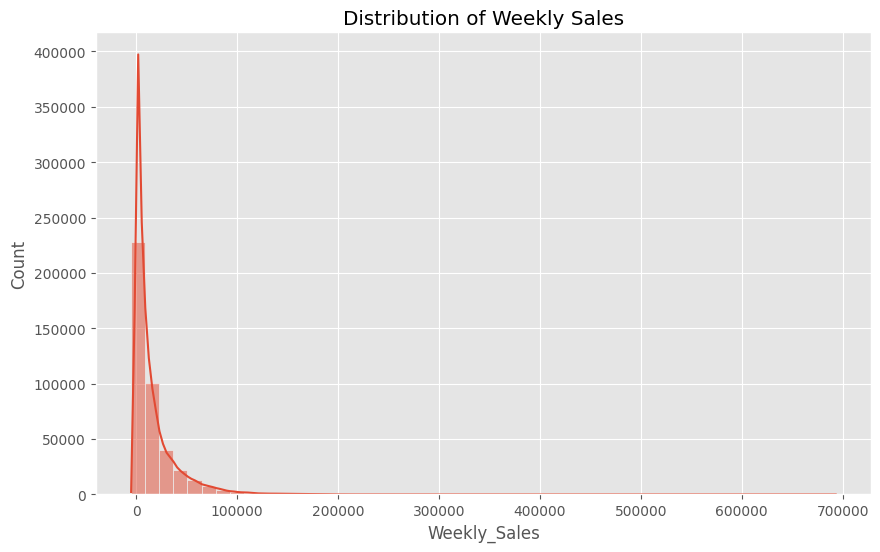

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(df["Weekly_Sales"],
             bins=50,
             kde=True)

plt.title("Distribution of Weekly Sales")

plt.show()

- Weekly Sales Distribution

- Weekly sales are positively skewed, with most observations concentrated at lower values and a smaller number of very high sales values.

- The presence of high-value sales observations indicates peak demand events, likely associated with holidays or promotions. Inventory planning should account for these exceptional demand periods to avoid stock shortages.


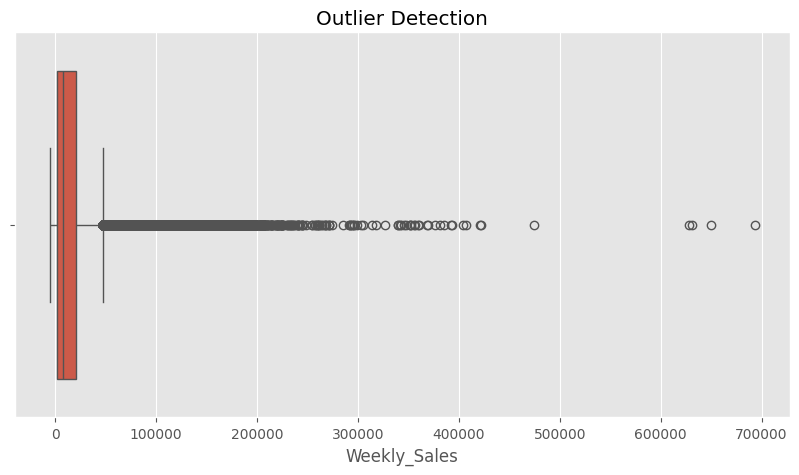

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["Weekly_Sales"])

plt.title("Outlier Detection")

plt.show()

- Outlier Detection

- Several observations lie far above the typical sales range.

- These outliers likely represent holiday periods, promotional campaigns, or exceptional demand events rather than data quality issues. Such observations should be retained because they reflect genuine business scenarios and are valuable for forecasting.


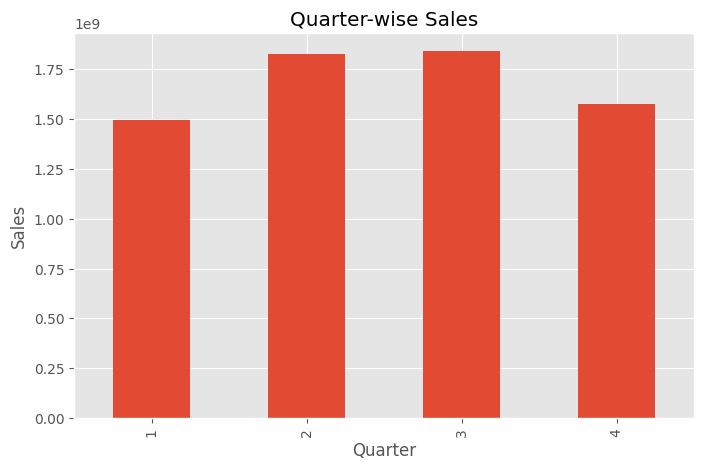

In [21]:
quarter = df.groupby("Quarter")["Weekly_Sales"].sum()

plt.figure(figsize=(8,5))

quarter.plot(kind="bar")

plt.title("Quarter-wise Sales")

plt.ylabel("Sales")

plt.show()

- Quarter-wise Sales

- Sales vary across quarters, with one or more quarters consistently outperforming others.

- Quarterly analysis enables management to identify seasonal demand cycles and optimize inventory procurement, staffing, and promotional activities before peak business periods.


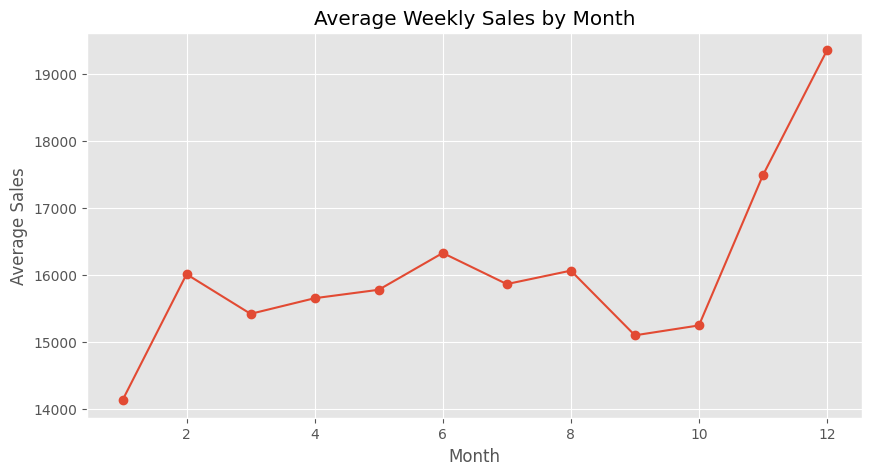

In [22]:
avg_month = df.groupby("Month")["Weekly_Sales"].mean()

plt.figure(figsize=(10,5))

avg_month.plot(marker='o')

plt.title("Average Weekly Sales by Month")

plt.ylabel("Average Sales")

plt.show()

- Average Weekly Sales by Month

- Average weekly sales differ across months, indicating recurring seasonal demand.

- Seasonal fluctuations suggest that inventory replenishment strategies should be adjusted monthly rather than applying a uniform inventory policy throughout the year.


In [23]:
top_combo = (
    df.groupby(["Store","Dept"])["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

print(top_combo)

Store  Dept
14     92      26101497.71
2      92      23572153.03
20     92      23542625.04
13     92      23170876.20
4      92      22789210.43
20     95      21537795.62
4      95      21054815.74
27     92      20952094.22
14     95      20655911.35
2      95      20533191.52
10     72      20410926.56
13     95      19568811.27
1      92      19370632.64
31     92      18162446.96
24     92      17429136.57
1      95      17270404.89
27     95      17091275.76
41     92      16563355.96
13     90      16529671.45
19     92      16261990.45
Name: Weekly_Sales, dtype: float64


- Top 20 Store–Department Combinations

- Certain store–department combinations contribute substantially more revenue than others.

- These high-performing combinations should receive priority in inventory allocation and promotional planning. Understanding their success factors can help replicate similar strategies across other stores and departments.

In [24]:
store_summary = df.groupby("Store").agg(
    Total_Sales=("Weekly_Sales","sum"),
    Average_Sales=("Weekly_Sales","mean")
)

store_summary.to_csv("Store_Summary.csv")

dept_summary = df.groupby("Dept").agg(
    Total_Sales=("Weekly_Sales","sum")
)

dept_summary.to_csv("Department_Summary.csv")

print("Summary Files Exported Successfully.")

Summary Files Exported Successfully.
